## 기본 통계량 및 분포 분석

# 지역별 숙소 개수 -> 현황 및 시각화 추가 할 거 있으면 추가

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df_clean = pd.read_csv("data/first_clean_data.csv")
clean = df_clean.copy()

In [3]:
clean.shape

(22248, 39)

In [4]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 22248 entries, 0 to 22247
Data columns (total 39 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0                                    22248 non-null  int64  
 1   id                                            22248 non-null  int64  
 2   name                                          22248 non-null  str    
 3   description                                   22248 non-null  str    
 4   host_id                                       22248 non-null  int64  
 5   host_since                                    22248 non-null  str    
 6   host_response_time                            22248 non-null  float64
 7   host_response_rate                            22248 non-null  float64
 8   host_acceptance_rate                          22248 non-null  float64
 9   host_is_superhost                             22248 non-null  str    
 1

In [5]:
clean['neighbourhood_group_cleansed'].value_counts()

neighbourhood_group_cleansed
Manhattan        10165
Brooklyn          7442
Queens            3414
Bronx              911
Staten Island      316
Name: count, dtype: int64

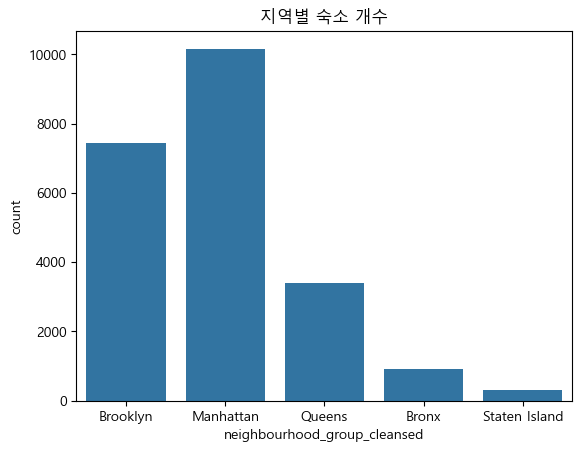

In [6]:
sns.countplot(data=clean, x='neighbourhood_group_cleansed') 
plt.title('지역별 숙소 개수')
plt.show()

1. 시각화 해석
- 뉴욕airbnb숙소는 manhattan과 brooklyn 지역에 많이 분포되어 있고 특히 manhattan이 가장 많은 숙소를 보유한 지역으로 나타남. 반면 bronx랑 statenlsland는 다른 지역에 비해 상대적으로 적은 숙소수를 나타내고 있다.

In [7]:
clean['room_type'].value_counts()

room_type
Entire home/apt    12635
Private room        9178
Hotel room           365
Shared room           70
Name: count, dtype: int64

# 지역별 숙소 유형 개수(한번 확인해봤음)

In [8]:
pd.crosstab(clean['neighbourhood_group_cleansed'],clean['room_type']).reset_index()

room_type,neighbourhood_group_cleansed,Entire home/apt,Hotel room,Private room,Shared room
0,Bronx,370,0,541,0
1,Brooklyn,3772,17,3623,30
2,Manhattan,6928,340,2880,17
3,Queens,1408,8,1975,23
4,Staten Island,157,0,159,0


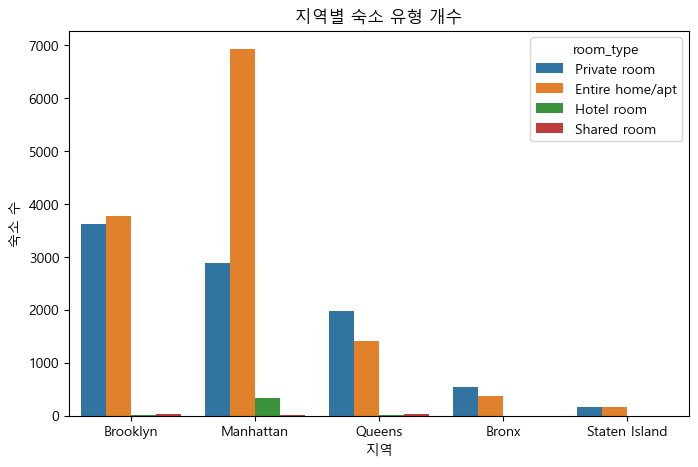

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=clean, x='neighbourhood_group_cleansed', hue='room_type')
plt.title('지역별 숙소 유형 개수')
plt.xlabel('지역')
plt.ylabel('숙소 수')
plt.show()

1. 시각화 해석
- 지역별 숙소 유형 분포를 살펴보면 Entire home/apt 유형은 Manhattan 지역에서 가장 높은 비중을 차지하는 것으로 나타났고, 반면 Private room 유형은 Brooklyn 지역에서 상대적으로 더 많이 분포하는 경향을 보인다. 나머지는 뭐....

# 개수보단 비율로 시각화 한번 도전!

In [10]:
pd.crosstab(clean['neighbourhood_group_cleansed'], clean['room_type'], normalize='index').round(2)

room_type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood_group_cleansed,,,,
Bronx,0.41,0.00,0.59,0.00
Brooklyn,0.51,0.00,0.49,0.00
Manhattan,0.68,0.03,0.28,0.00
Queens,0.41,0.00,0.58,0.01
Staten Island,0.50,0.00,0.50,0.00


In [11]:
# normalize로 비율 분석(지역별 숙소유형 개수 시각화)
ct = pd.crosstab(clean['neighbourhood_group_cleansed'], clean['room_type'], normalize='index').round(2)

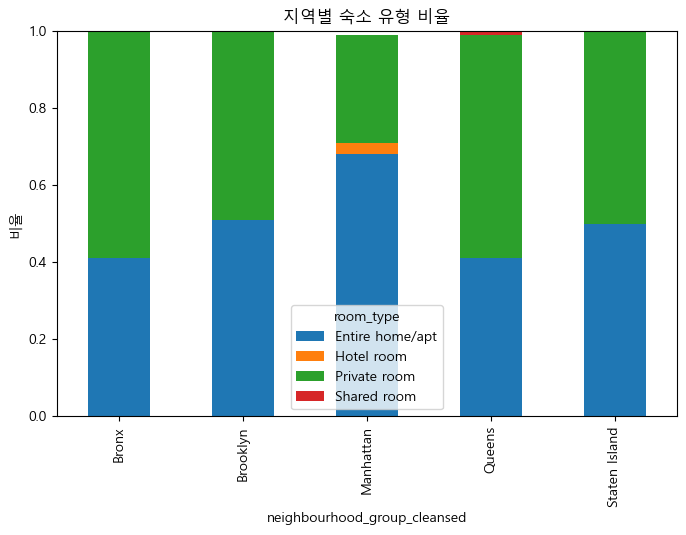

In [12]:
# 음... 망했다....
ct.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title("지역별 숙소 유형 비율")
plt.ylabel("비율")
plt.show()

In [13]:
# 지역별 숙소 개수 비율로 시각화
clean['neighbourhood_group_cleansed'].value_counts(normalize=False)

neighbourhood_group_cleansed
Manhattan        10165
Brooklyn          7442
Queens            3414
Bronx              911
Staten Island      316
Name: count, dtype: int64

In [14]:
region = clean['neighbourhood_group_cleansed'].value_counts(normalize=True) * 100
region = region.round(2)

region

neighbourhood_group_cleansed
Manhattan        45.69
Brooklyn         33.45
Queens           15.35
Bronx             4.09
Staten Island     1.42
Name: proportion, dtype: float64

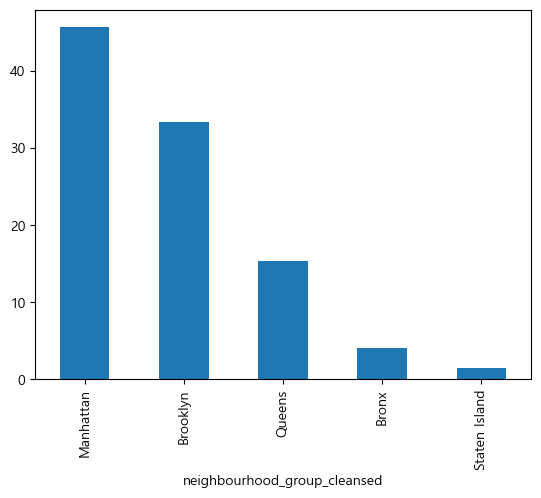

In [15]:
region.plot(kind='bar')
plt.show()

어떤 유형들 중에서 더 많은 가격에 미치는 영향을 상관계수 구해봤다?

가장 상관계수가 높은 것들의 특징들을 검정하고 연관이있는지 확인 유형자체와 어떤컬럼이 상관관계가 있는지 숙소유형평균가격이랑 어떤컬럼이 상관관계가 있는지

어떤것들이 가격에영향을 미치는지??

In [16]:
clean.dtypes

Unnamed: 0                                        int64
id                                                int64
name                                                str
description                                         str
host_id                                           int64
host_since                                          str
host_response_time                              float64
host_response_rate                              float64
host_acceptance_rate                            float64
host_is_superhost                                   str
neighbourhood_cleansed                              str
neighbourhood_group_cleansed                        str
latitude                                        float64
longitude                                       float64
property_type                                       str
room_type                                           str
accommodates                                      int64
bedrooms                                        

In [17]:
clean.columns

Index(['Unnamed: 0', 'id', 'name', 'description', 'host_id', 'host_since',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds',
       'amenities', 'price', 'availability_365', 'number_of_reviews',
       'number_of_reviews_ltm', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month',
       'log_price'],
      dtype='str')

In [18]:
print(clean.dtypes.to_string())

Unnamed: 0                                        int64
id                                                int64
name                                                str
description                                         str
host_id                                           int64
host_since                                          str
host_response_time                              float64
host_response_rate                              float64
host_acceptance_rate                            float64
host_is_superhost                                   str
neighbourhood_cleansed                              str
neighbourhood_group_cleansed                        str
latitude                                        float64
longitude                                       float64
property_type                                       str
room_type                                           str
accommodates                                      int64
bedrooms                                        

# 숙소유형별 범주vs범주로 크래머v계수 활용해 상관관계 찾기
- 일단 범주 VS 범주 컬럼 추린 결과
neighbourhood_group_cleansed,
host_is_superhost,
property_type
3개 밖에 생각 안남....

In [19]:
from scipy.stats import chi2_contingency

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v

In [20]:
ct = pd.crosstab(clean['room_type'], clean['neighbourhood_group_cleansed'])
cramers_v(ct)

np.float64(0.15705648117352444)

- 숙소유형과 지역은 0.157로 약한 상관관계가 있다.

In [21]:
ct2 = pd.crosstab(clean['room_type'], clean['host_is_superhost'])
cramers_v(ct2)

np.float64(0.06156069544850748)

- 숙소유형과 슈퍼호스트는 0.0615로 상관관계가 없다라고 판단된다.

In [22]:
ct3 = pd.crosstab(clean['room_type'], clean['property_type'])
cramers_v(ct3)

np.float64(0.8838083381858214)

- 방유형과 숙소유형은 0.88로 강한 상관관계를 맺고 있음... 당연한거 아닌가???
- property_type은 room_type의 세부 분류로
  두 컬럼이 본질적으로 같은 정보를 담고 있어
  강한 상관관계(0.88)가 나온 것은 당연한 결과로 분석에서 제외함

범주vs범주는 이게 끝????
결과: 지역이랑 숙소유형이 있는데 지역이 약한 상관관계가 있다는걸로 나와 유의미한 결과라고 보여진다??

In [23]:
clean['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Hotel room', 'Shared room']
Length: 4, dtype: str

In [24]:
clean['property_type'].unique()

<StringArray>
[       'Private room in rental unit',              'Private room in condo',
               'Private room in home',                        'Entire home',
                 'Entire rental unit',        'Private room in guest suite',
                       'Entire place',                        'Entire loft',
                       'Entire condo',          'Private room in townhouse',
                   'Entire townhouse',  'Private room in bed and breakfast',
          'Entire serviced apartment',               'Private room in loft',
                  'Entire guesthouse',                 'Entire guest suite',
          'Private room in houseboat',             'Room in boutique hotel',
                       'Private room',         'Shared room in rental unit',
                               'Boat',         'Room in serviced apartment',
              'Private room in villa', 'Private room in religious building',
                    'Casa particular',                'Shared 

# 범주 vs 수치로 ANOVA 검정 실행

- room_type vs 수용인원
- room_type vs 침실수
- room_type vs 침대수
흠.... 나머지는 모르겠음....

In [25]:
clean.select_dtypes(include='number').columns

Index(['Unnamed: 0', 'id', 'host_id', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'latitude', 'longitude',
       'accommodates', 'bedrooms', 'beds', 'price', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm',
       'estimated_occupancy_l365d', 'estimated_revenue_l365d',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month',
       'log_price'],
      dtype='str')

1. 가설 설정
- 귀무가설 : 방 유형별로 수용인원의 차이가 없다.
- 대립가설 : 방 유형별로 수용인원이 1개라도 차이가 있다.

In [26]:
clean['room_type'].value_counts()

room_type
Entire home/apt    12635
Private room        9178
Hotel room           365
Shared room           70
Name: count, dtype: int64

In [27]:
# 일단 room_type vs 수용인원부터 anova 검정 ㄱㄱ
clean['accommodates'].value_counts()

accommodates
2     10412
1      3569
4      3417
3      1721
6      1209
5       802
8       481
7       198
10      130
16       98
12       90
9        64
11       22
14       15
15       13
13        7
Name: count, dtype: int64

- 3그룹 이상 각각 구하는거니 일원 anova 정규성 검정

In [28]:
ac1 = clean.loc[clean['room_type'] == 'Entire home/apt', 'accommodates']
ac2 = clean.loc[clean['room_type'] == 'Private room', 'accommodates']
ac3 = clean.loc[clean['room_type'] == 'Hotel room', 'accommodates']
ac4 = clean.loc[clean['room_type'] == 'Shared room', 'accommodates']

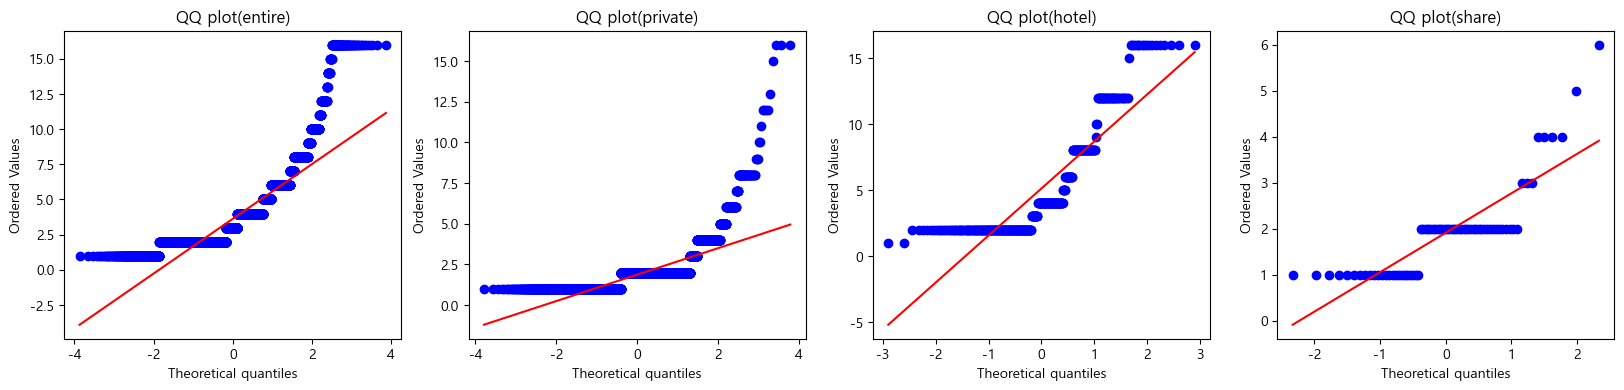

In [29]:
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(ac1, plot=ax[0])
ax[0].set_title("QQ plot(entire)")
stats.probplot(ac2, plot=ax[1])
ax[1].set_title("QQ plot(private)")
stats.probplot(ac3, plot=ax[2])
ax[2].set_title("QQ plot(hotel)")
stats.probplot(ac4, plot=ax[3])
ax[3].set_title("QQ plot(share)")
plt.show()

- 일단 정규성을 안뛰는데 이렇게도 시각화로 나오나?? 수용인원(이산형)이라 계단식으로 나온듯..
- 정규성을 안뛰어서 크루스칼 왈리스로 p-value 확인

In [30]:
clean['accommodates'].unique()

array([ 1,  2,  3,  5, 16,  4,  8,  7, 12,  6,  9, 10, 14, 11, 15, 13])

In [31]:
stat, p = stats.kruskal(ac1, ac2, ac3, ac4)
stat, p

(np.float64(6648.260919820135), np.float64(0.0))

유의 수준 0.05로 잡고 확인

- 확인 결과: p-value 0.0으로 0에 매우 근접해서 유의수준에 한참 미치지 못해 귀무가설 기각

- 그러므로 대립가설 채택
- 결론: 방 유형별로 수용인원의 차이가 있다.

2. 사후검정(dunn test)

In [32]:
import scikit_posthocs as sp

data = pd.DataFrame({
    'value': pd.concat([ac1, ac2, ac3, ac4]),
    'group': ['Entire home']*len(ac1) + ['Private room']*len(ac2) + 
             ['Hotel room']*len(ac3) + ['Shared room']*len(ac4)
})

posthoc = sp.posthoc_dunn(data,
                          val_col='value',
                          group_col='group',
                          p_adjust='holm')
print(posthoc)

               Entire home     Hotel room   Private room   Shared room
Entire home   1.000000e+00   9.121861e-04   0.000000e+00  2.458253e-18
Hotel room    9.121861e-04   1.000000e+00  3.132237e-128  4.611173e-21
Private room  0.000000e+00  3.132237e-128   1.000000e+00  7.284464e-01
Shared room   2.458253e-18   4.611173e-21   7.284464e-01  1.000000e+00


- private room -> shared room은 숙소유형별 수용인원 차이가 없다.(0.728)
- 나머지는 숙소유형별 차이가 있다.

# room_type vs 침실 수 ANOVA 검정

1. 가설 설정
- 귀무가설: 방 유형별로 침실 수가 차이가 없다.
- 대립가설: 방 유형별로 침실 수가 1개라도 차이가 있다.

In [33]:
clean.columns

Index(['Unnamed: 0', 'id', 'name', 'description', 'host_id', 'host_since',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds',
       'amenities', 'price', 'availability_365', 'number_of_reviews',
       'number_of_reviews_ltm', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month',
       'log_price'],
      dtype='str')

In [34]:
clean['bedrooms'].value_counts()

bedrooms
1.0     14126
2.0      3863
0.0      2137
3.0      1442
4.0       448
5.0       156
6.0        52
7.0        13
9.0         5
8.0         4
14.0        1
15.0        1
Name: count, dtype: int64

In [35]:
clean['bedrooms'].unique()

array([ 1.,  5.,  2.,  0.,  3.,  4., 14.,  6.,  7.,  9.,  8., 15.])

In [36]:
clean['bedrooms'].isna().sum()

np.int64(0)

In [37]:
# float형 데이터를 int로 바꾸고 시작
clean['bedrooms'] = clean['bedrooms'].astype(int)

In [38]:
clean['bedrooms'].value_counts()

bedrooms
1     14126
2      3863
0      2137
3      1442
4       448
5       156
6        52
7        13
9         5
8         4
14        1
15        1
Name: count, dtype: int64

침실수가 0개??

In [39]:
clean['room_type'].value_counts()

room_type
Entire home/apt    12635
Private room        9178
Hotel room           365
Shared room           70
Name: count, dtype: int64

In [40]:
clean.loc[clean['bedrooms'] == 0, 'room_type'].value_counts()

room_type
Entire home/apt    1868
Private room        259
Shared room           6
Hotel room            4
Name: count, dtype: int64

- 0개가 생각보다 좀 있네.... 일단 그대로 두고
- 3그룹 이상 각각 구하는거니 일원 anova

In [41]:
bed1 = clean.loc[clean['room_type'] == 'Entire home/apt', 'bedrooms']
bed2 = clean.loc[clean['room_type'] == 'Private room', 'bedrooms']
bed3 = clean.loc[clean['room_type'] == 'Hotel room', 'bedrooms']
bed4 = clean.loc[clean['room_type'] == 'Shared room', 'bedrooms']

2. q-q plot 정규성 검정

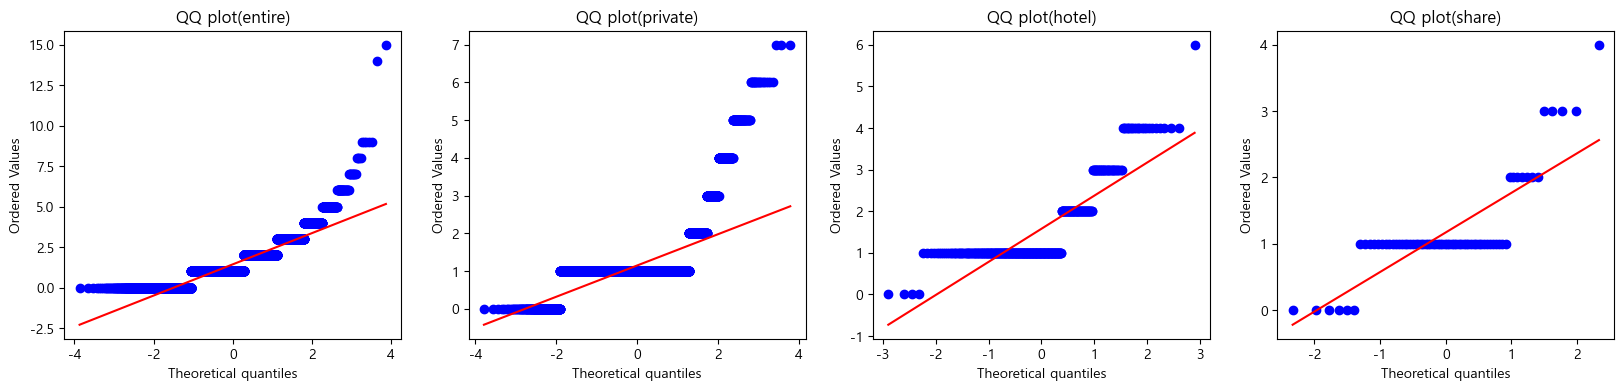

In [42]:
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(bed1, plot=ax[0])
ax[0].set_title("QQ plot(entire)")
stats.probplot(bed2, plot=ax[1])
ax[1].set_title("QQ plot(private)")
stats.probplot(bed3, plot=ax[2])
ax[2].set_title("QQ plot(hotel)")
stats.probplot(bed4, plot=ax[3])
ax[3].set_title("QQ plot(share)")
plt.show()

정규성을 뛰지 않아 크루스칼 왈리스(유의수준 0.05로 잡음)

In [43]:
stat, p = stats.kruskal(bed1, bed2, bed3, bed4)
stat, p

(np.float64(669.6543124602632), np.float64(7.978589906254915e-145))

p-value의 값이 0에 가까운 값이므로 유의수준보다 한참 못 미쳐 귀무가설 기각 대립가설 채택
- 결론: 방 유형별로 침실 수가 1개라도 차이가 있다. 

마지막 사후 검정(dunn test)

In [44]:
data = pd.DataFrame({
    'value': pd.concat([bed1, bed2, bed3, bed4]),
    'group': ['Entire home']*len(bed1) + ['Private room']*len(bed2) + 
             ['Hotel room']*len(bed3) + ['Shared room']*len(bed4)
})

posthoc = sp.posthoc_dunn(data,
                          val_col='value',
                          group_col='group',
                          p_adjust='holm')
print(posthoc)

                Entire home    Hotel room   Private room  Shared room
Entire home    1.000000e+00  6.856089e-03  4.063005e-139     0.024873
Hotel room     6.856089e-03  1.000000e+00   1.004390e-20     0.001618
Private room  4.063005e-139  1.004390e-20   1.000000e+00     0.702913
Shared room    2.487341e-02  1.618043e-03   7.029134e-01     1.000000


- 결과: 수용인원이랑 똑같이 private room이랑 shared room만 차이가 없다라고 나오고 나머지는 차이가 있다라고 나옴...

# # room_type vs 침대 수 ANOVA 검정

1. 가설설정
- 귀무가설: 방 유형별 침대수의 차이가 없다.
- 대립가설: 방 유형별 침대수가 1개라도 차이가 있다.

In [45]:
clean.columns

Index(['Unnamed: 0', 'id', 'name', 'description', 'host_id', 'host_since',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds',
       'amenities', 'price', 'availability_365', 'number_of_reviews',
       'number_of_reviews_ltm', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month',
       'log_price'],
      dtype='str')

In [46]:
clean['beds'].value_counts()

beds
1.0     13014
2.0      5132
3.0      1893
4.0       911
0.0       634
5.0       328
6.0       180
7.0        66
8.0        54
9.0        17
10.0        7
12.0        4
13.0        3
11.0        2
42.0        1
14.0        1
21.0        1
Name: count, dtype: int64

In [47]:
clean['beds'].isna().sum()

np.int64(0)

In [48]:
clean['beds'] = clean['beds'].astype(int)

In [49]:
clean['beds'].value_counts()

beds
1     13014
2      5132
3      1893
4       911
0       634
5       328
6       180
7        66
8        54
9        17
10        7
12        4
13        3
11        2
42        1
14        1
21        1
Name: count, dtype: int64

- 일원 anova 진행

In [50]:
beds1 = clean.loc[clean['room_type'] == 'Entire home/apt', 'beds']
beds2 = clean.loc[clean['room_type'] == 'Private room', 'beds']
beds3 = clean.loc[clean['room_type'] == 'Hotel room', 'beds']
beds4 = clean.loc[clean['room_type'] == 'Shared room', 'beds']

q-q plot 정규성 검정

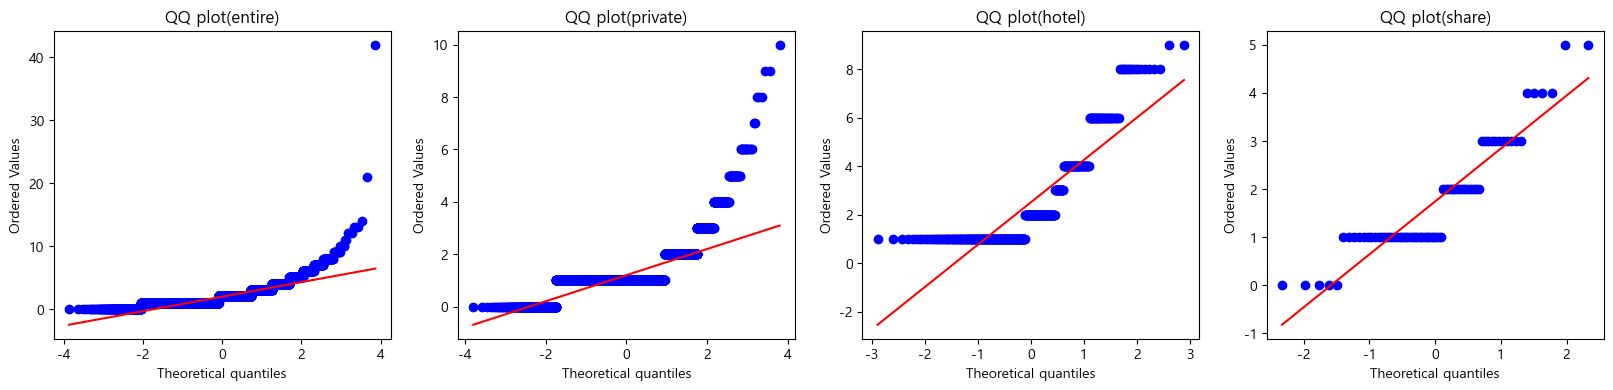

In [51]:
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(beds1, plot=ax[0])
ax[0].set_title("QQ plot(entire)")
stats.probplot(beds2, plot=ax[1])
ax[1].set_title("QQ plot(private)")
stats.probplot(beds3, plot=ax[2])
ax[2].set_title("QQ plot(hotel)")
stats.probplot(beds4, plot=ax[3])
ax[3].set_title("QQ plot(share)")
plt.show()

계단식 형태로 정규성 안뜀 1번사진이 4개중에 괜찮은 느낌?
- 그러므로 크루스칼 왈리스 시행(유의수준은 0.05)

In [52]:
stat, p = stats.kruskal(beds1, beds2, beds3, beds4)
stat, p

(np.float64(3064.47174802314), np.float64(0.0))

0.0으로 유의수준에 못미쳐서 귀무가설 기각 대립가설 채택
결론: 방 유형별로 침대수가 차이가 있다.

사후검정(어떤게 차이가 있는지 없는지 dunn test)

In [53]:
data = pd.DataFrame({
    'value': pd.concat([beds1, beds2, beds3, beds4]),
    'group': ['Entire home']*len(beds1) + ['Private room']*len(beds2) + 
             ['Hotel room']*len(beds3) + ['Shared room']*len(beds4)
})

posthoc = sp.posthoc_dunn(data,
                          val_col='value',
                          group_col='group',
                          p_adjust='holm')
print(posthoc)

              Entire home    Hotel room  Private room  Shared room
Entire home      1.000000  1.474208e-02  0.000000e+00     0.112823
Hotel room       0.014742  1.000000e+00  6.262106e-63     0.018594
Private room     0.000000  6.262106e-63  1.000000e+00     0.000012
Shared room      0.112823  1.859419e-02  1.249233e-05     1.000000


결과: shared room과 entire home은 유의수준 0.112로 0.05보다 높으므로 차이가 없다라고 볼 수 있다.
나머지는 차이가 있다.(침대 수)

In [54]:
print(clean.groupby('room_type')['bedrooms'].mean())
print(clean.groupby('room_type')['beds'].mean())

room_type
Entire home/apt    1.430708
Hotel room         1.578082
Private room       1.146655
Shared room        1.171429
Name: bedrooms, dtype: float64
room_type
Entire home/apt    1.945865
Hotel room         2.504110
Private room       1.198736
Shared room        1.742857
Name: beds, dtype: float64


통계적으로 차이가 있다로 나왔으니 피어슨으로 수치vs수치해서 상관관계 확인

In [55]:
clean[['accommodates', 'bedrooms', 'beds', 'price']].corr(method='pearson')

,accommodates,bedrooms,beds,price
accommodates,1.000000,0.595693,0.734593,0.283347
bedrooms,0.595693,1.000000,0.641898,0.177434
beds,0.734593,0.641898,1.000000,0.197095
price,0.283347,0.177434,0.197095,1.000000


보니 전체적으로 3개다 price랑 약한 상관관계가 보이고 accommodates는 그중 0.283으로 젤 높은 상관관계를 뛴다.

# 호스트 응답률별 가격 통계 검정(수치vs수치 이므로 pearson), 유의수준 0.05

호스트 응답률과 가격간의 차이를 보기위해 피어슨으로 상관관계부터 확인

In [92]:
# 호스트 응답률 확인
clean['host_response_rate'].corr(clean['log_price'])

np.float64(0.003064356648582748)

0.002로 0에 가까움

<Axes: xlabel='host_response_rate', ylabel='log_price'>

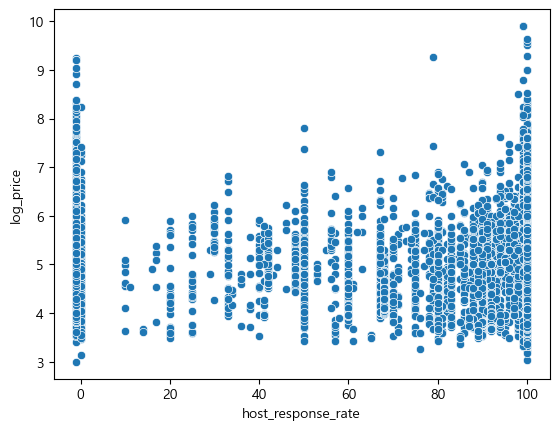

In [93]:
sns.scatterplot(data=clean, x='host_response_rate', y='log_price')

In [94]:
# 예약요청 수략률 확인
clean['host_acceptance_rate'].corr(clean['log_price'])

np.float64(0.09463012881439758)

0.01로 약한 상관관계 확인됨

<Axes: xlabel='host_acceptance_rate', ylabel='log_price'>

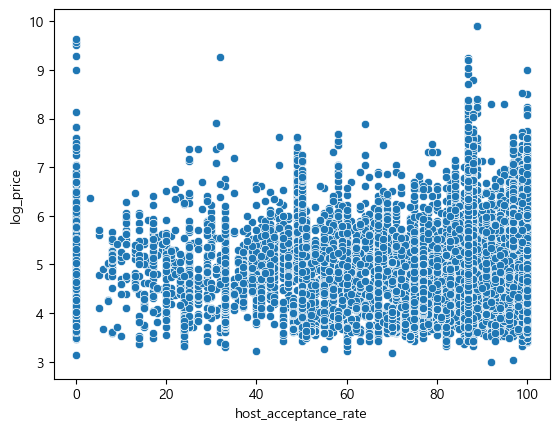

In [95]:
sns.scatterplot(data=clean, x='host_acceptance_rate', y='log_price')

In [73]:
clean['host_response_rate'].value_counts()

host_response_rate
 100.0    12858
-1.0       4389
 99.0       719
 98.0       549
 0.0        436
          ...  
 16.0         1
 43.0         1
 55.0         1
 11.0         1
 62.0         1
Name: count, Length: 66, dtype: int64

In [ ]:
# 통계 검정위해 -1로 처리한건 제외 후 검정
clean_response = clean[clean['host_response_rate'] >= 0]

In [ ]:
# 호스트 응답률별로 구간 0~50, 90, 100 cut로 나누기
clean_response['response_group'] = pd.cut(clean_response['host_response_rate'], bins=[0,50,90,100], labels=['low', 'mid', 'high'])

In [96]:
clean_response.groupby('response_group')['log_price'].mean()

response_group
low     4.865912
mid     4.723559
high    5.025156
Name: log_price, dtype: float64

In [97]:
clean_response.groupby('response_group')['log_price'].describe()

,count,mean,std,min,25%,50%,75%,max
response_group,,,,,,,,
low,609.0,4.865912,0.612929,3.433987,4.564348,4.836282,5.214936,7.810353
mid,1722.0,4.723559,0.663760,3.258097,4.262680,4.644391,5.111988,9.274723
high,15092.0,5.025156,0.795755,3.044522,4.454347,5.010635,5.564520,9.903538


- 확실히 응답률이 100%일때의 가격이 5.02로 가장 높다.

# 그래서 구간을 3개로 나눠 그룹해서 anova 검정

1. 가설 설정
- 귀무가설: 응답률 그룹별로 가격간의 차이가 없다.
- 대립가설: 응답률 그룹별로 가격간의 차이가 적어도 1개라도 있다.

In [98]:
low = clean_response[clean_response['response_group']=='low']['log_price']
mid = clean_response[clean_response['response_group']=='mid']['log_price']
high = clean_response[clean_response['response_group']=='high']['log_price']

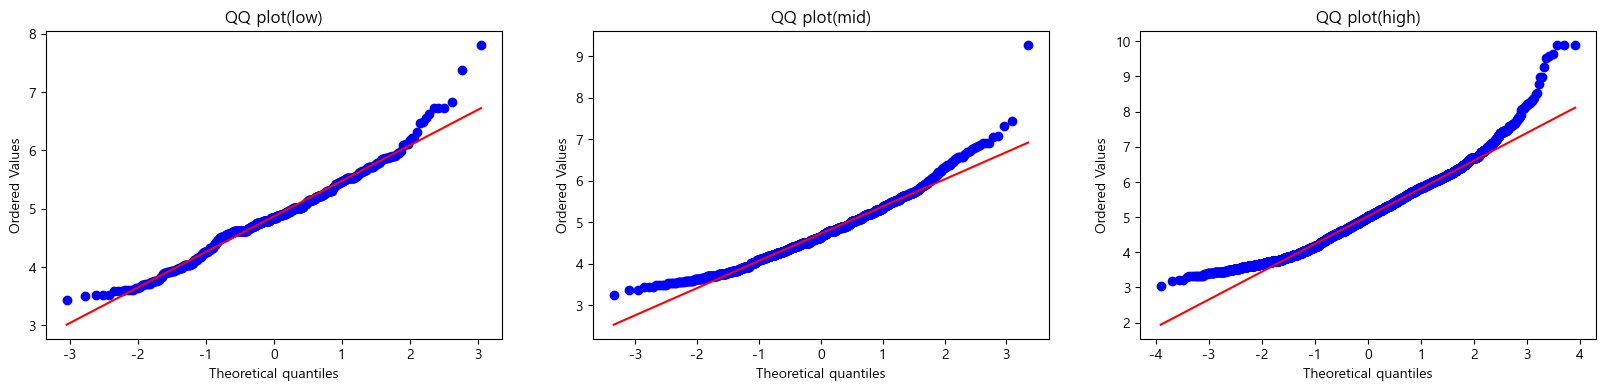

In [99]:
# 일원 anova(정규성 검정 q-q plot)
fig, ax = plt.subplots(1,3, figsize=(20,4))
stats.probplot(low, plot=ax[0])
ax[0].set_title("QQ plot(low)")
stats.probplot(mid, plot=ax[1])
ax[1].set_title("QQ plot(mid)")
stats.probplot(high, plot=ax[2])
ax[2].set_title("QQ plot(high)")
plt.show()

정규성에 살짝 근접하나 하나씩 극단값들이 존재해 정규성x 그러므로 크루스칼 왈리스 검정

In [100]:
# 유의수준 0.05
stat, p = stats.kruskal(low, mid, high)
stat, p

(np.float64(265.2227548815556), np.float64(2.5562924649512178e-58))

In [101]:
if p < 0.05:
    print("그룹 간 가격 차이 있음")
else:
    print("그룹 간 가격 차이 없음")

그룹 간 가격 차이 있음


- p-value값이 0에 가까우므로 그룹간 가격 차이 있음

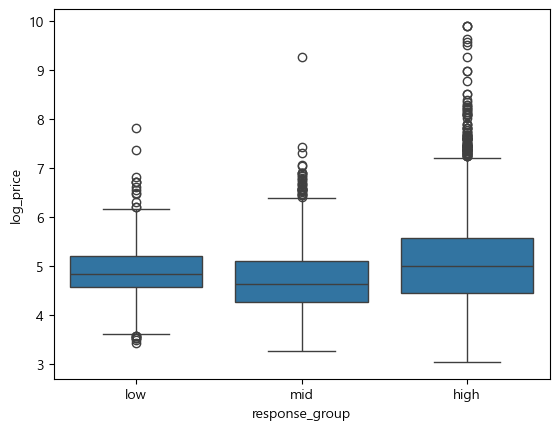

In [103]:
# 호스트 응답률별로 어떤그룹의 차이가 젤 높은지 확인하기 위한 boxplot
sns.boxplot(x='response_group', y='log_price', data=clean_response)
plt.show()

- high그룹이 100%응답률을가진 곳인데 확실히 가격의 극단값이 가장 높게 나타남.